# 02 – EDA Fraud PaySim

Thực hiện: Khải; kiểm chứng/phụ trách hạng mục: Châm. Phân tích type, thời gian, amount, tài khoản và balance; ground truth là `isFraud`.

In [1]:
from pathlib import Path
import hashlib, json, math, re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

SEED = 42
CHUNK_SIZE = 200_000
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks": ROOT = ROOT.parent
RAW_DIR = ROOT / "data" / "raw"
CSV_PATH = next((RAW_DIR / n for n in ["PS_20174392719_1491204439457_log.csv", "PaySim.csv"] if (RAW_DIR / n).exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError(f"Đặt PaySim tại {RAW_DIR} với một trong hai tên được hỗ trợ.")
OUT_DIR = ROOT / "docs" / "data"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)
EXPECTED_COLUMNS = ["step","type","amount","nameOrig","oldbalanceOrg","newbalanceOrig","nameDest","oldbalanceDest","newbalanceDest","isFraud","isFlaggedFraud"]
header = pd.read_csv(CSV_PATH, nrows=0).columns.tolist()
assert header == EXPECTED_COLUMNS, f"Schema không đúng: {header}"
sns.set_theme(style="whitegrid")
print(f"Nguồn: {CSV_PATH.name} | chunk={CHUNK_SIZE:,} | seed={SEED}")

Nguồn: PS_20174392719_1491204439457_log.csv | chunk=200,000 | seed=42


## 1. Tổng hợp theo type, thời gian, amount, tài khoản và balance

`isFraud` là ground truth; `isFlaggedFraud` chỉ được mô tả như cờ nguồn.

In [2]:
type_parts=[]; hour_parts=[]; day_parts=[]; band_parts=[]; amount_label_parts=[]; balance_parts=[]
orig_counts=Counter(); dest_counts=Counter(); fraud_orig=Counter(); fraud_dest=Counter(); prefix_orig=Counter(); prefix_dest=Counter()
total_amount=fraud_amount=0.; old_dest_zero_fraud=full_drain_fraud=fraud_total=0
bins=[-np.inf,1000,10000,100000,1000000,10000000,np.inf]; labels=["XS","S","M","L","XL","XXL"]
for ch in pd.read_csv(CSV_PATH,chunksize=CHUNK_SIZE):
    ch["HourOfDay"]=(ch.step-1)%24; ch["StepDay"]=(ch.step-1)//24+1
    ch["AmountBand"]=pd.cut(ch.amount,bins=bins,labels=labels,right=False)
    for cols,target in [(["type"],type_parts),(["HourOfDay"],hour_parts),(["StepDay"],day_parts),(["AmountBand"],band_parts)]:
        target.append(ch.groupby(cols,observed=False).isFraud.agg(transaction_count="size",fraud_count="sum").reset_index())
    sample=pd.concat([g.sample(min(len(g),4000),random_state=SEED) for _,g in ch.groupby("isFraud")]); amount_label_parts.append(sample[["amount","isFraud"]])
    ch["BalanceDropOrig"]=ch.oldbalanceOrg-ch.newbalanceOrig; ch["BalanceChangeDest"]=ch.newbalanceDest-ch.oldbalanceDest
    balance_parts.append(ch.groupby("isFraud")[["BalanceDropOrig","BalanceChangeDest"]].agg(["mean","median"]))
    for k,v in ch.nameOrig.value_counts().items(): orig_counts[k]+=int(v)
    for k,v in ch.nameDest.value_counts().items(): dest_counts[k]+=int(v)
    fr=ch[ch.isFraud.eq(1)]; fraud_total+=len(fr)
    for k,v in fr.nameOrig.value_counts().items(): fraud_orig[k]+=int(v)
    for k,v in fr.nameDest.value_counts().items(): fraud_dest[k]+=int(v)
    for k,v in ch.nameOrig.str[0].value_counts().items(): prefix_orig[k]+=int(v)
    for k,v in ch.nameDest.str[0].value_counts().items(): prefix_dest[k]+=int(v)
    old_dest_zero_fraud+=int(fr.oldbalanceDest.eq(0).sum())
    full_drain_fraud+=int((np.isclose(fr.oldbalanceOrg-fr.amount,0,atol=.01)&fr.newbalanceOrig.eq(0)).sum())
    total_amount+=float(ch.amount.sum()); fraud_amount+=float(fr.amount.sum())
def combine(parts,key):
    x=pd.concat(parts); return x.groupby(key,observed=False)[["transaction_count","fraud_count"]].sum().reset_index().assign(fraud_rate=lambda d:d.fraud_count/d.transaction_count)
by_type=combine(type_parts,"type"); by_hour=combine(hour_parts,"HourOfDay"); by_day=combine(day_parts,"StepDay"); by_band=combine(band_parts,"AmountBand")
display(by_type); display(by_hour); display(by_day); display(by_band)

,type,transaction_count,fraud_count,fraud_rate
0,CASH_IN,1399284,0,0.000000
1,CASH_OUT,2237500,4116,0.001840
2,DEBIT,41432,0,0.000000
3,PAYMENT,2151495,0,0.000000
4,TRANSFER,532909,4097,0.007688


,HourOfDay,transaction_count,fraud_count,fraud_rate
0,0,27111,358,0.013205
1,1,9018,372,0.041251
2,2,2007,326,0.162431
3,3,1241,274,0.220790
4,4,1641,366,0.223035
5,5,3420,358,0.104678
6,6,8988,328,0.036493
7,7,26915,368,0.013673
8,8,283518,341,0.001203
9,9,425729,375,0.000881


,StepDay,transaction_count,fraud_count,fraud_rate
0,1,574255,271,0.000472
1,2,455238,309,0.000679
2,3,1070,310,0.289720
3,4,28240,262,0.009278
4,5,9789,252,0.025743
5,6,441005,228,0.000517
6,7,420583,272,0.000647
7,8,449637,278,0.000618
8,9,417919,255,0.000610
9,10,392945,282,0.000718


,AmountBand,transaction_count,fraud_count,fraud_rate
0,XS,142642,58,0.000407
1,S,1143361,220,0.000192
2,M,2239253,1429,0.000638
3,L,2706738,3800,0.001404
4,XL,124976,2419,0.019356
5,XXL,5650,287,0.050796


## 2. Biểu đồ và nhận xét

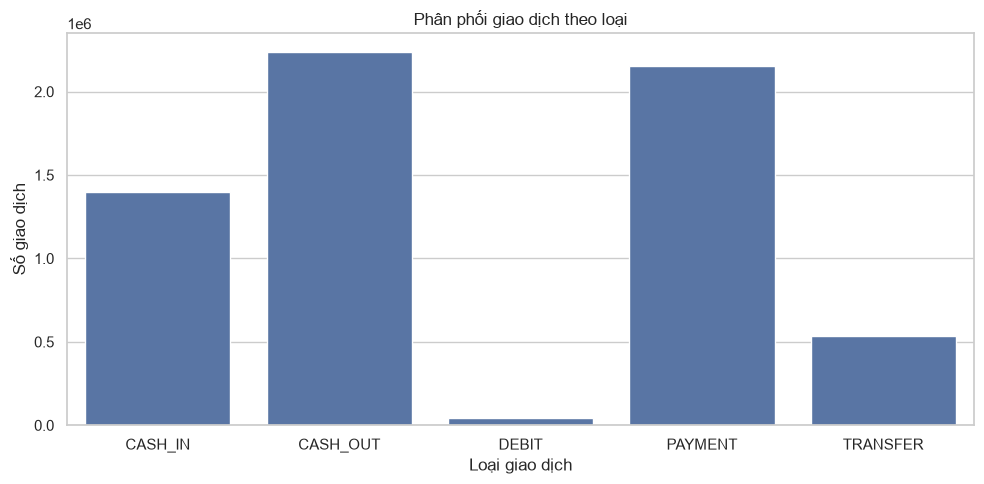

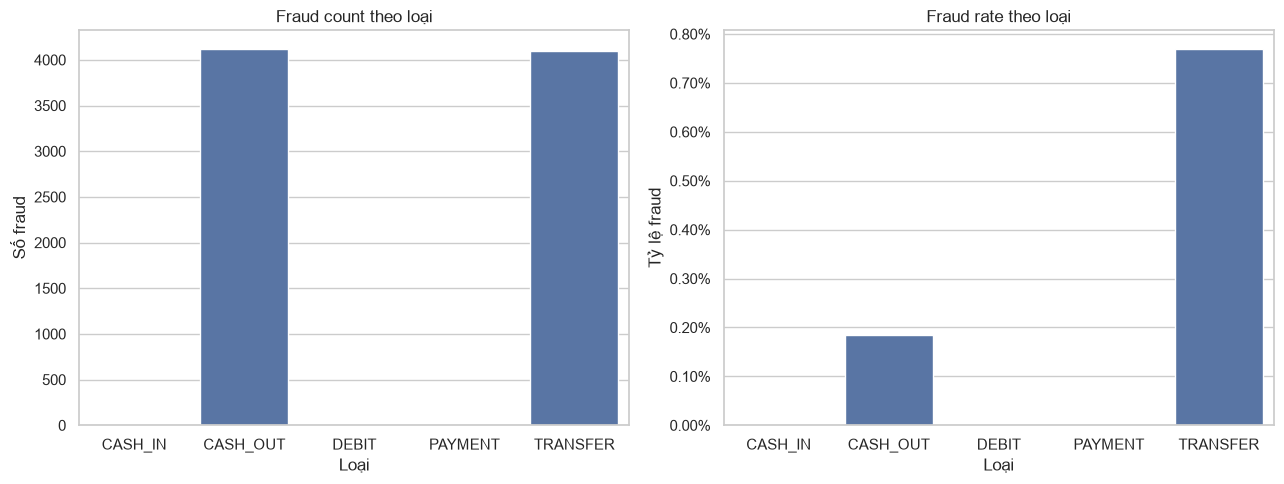

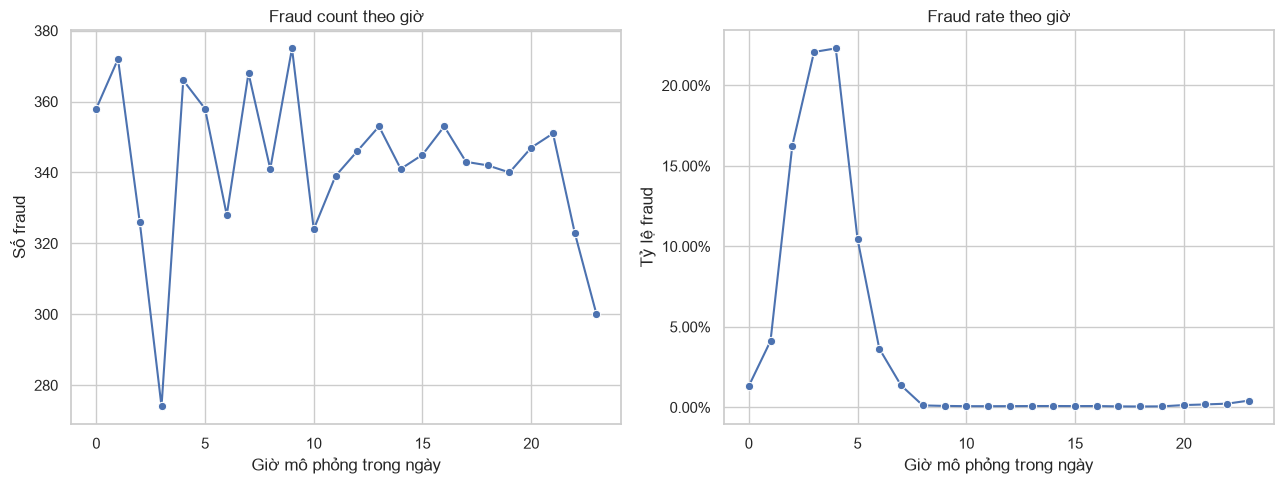

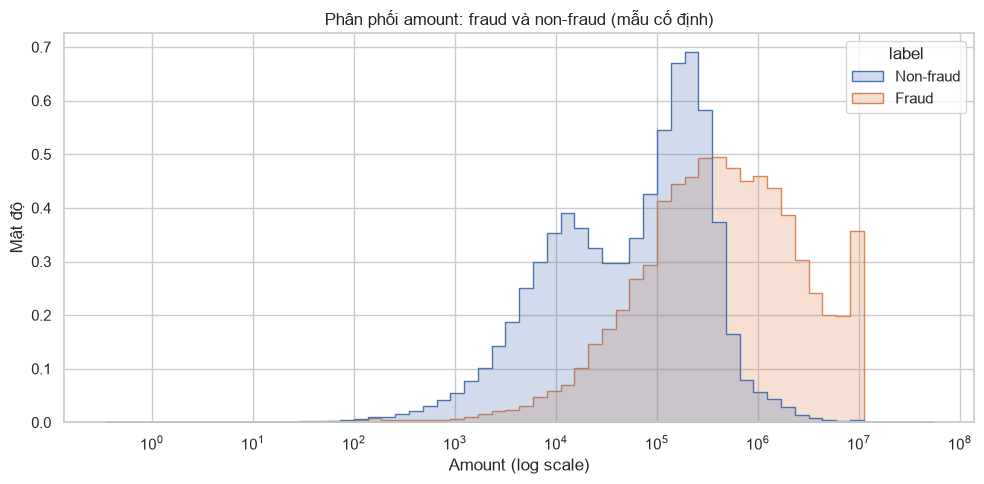

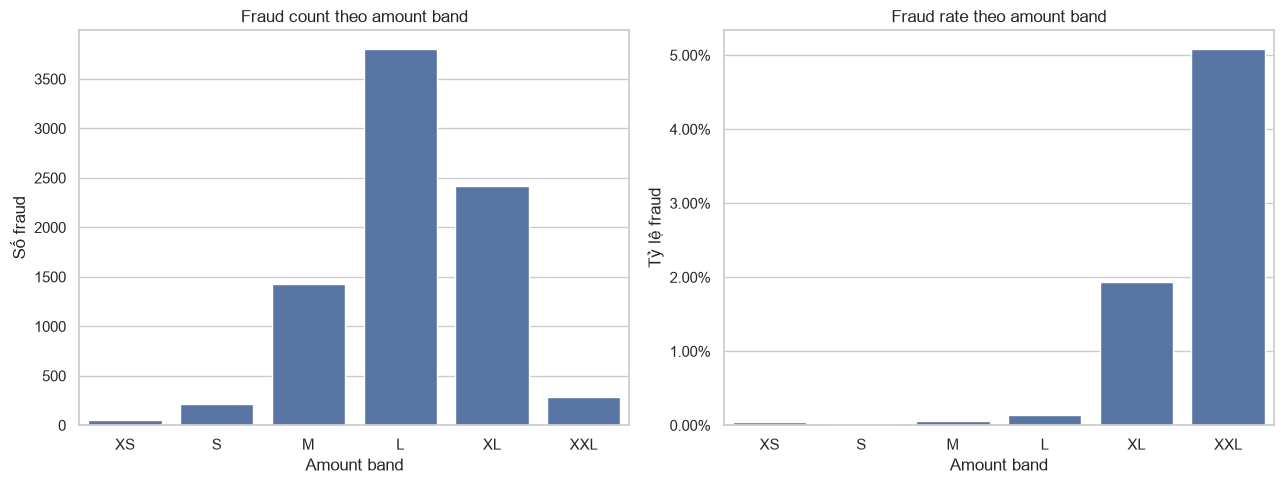

BalanceDropOrig                BalanceChangeDest             
                   mean         median              mean       median
isFraud                                                              
0         -2.315056e+04       0.000000     123241.690204     0.000000
1          1.419253e+06  423345.694844     724551.384869  4601.770312

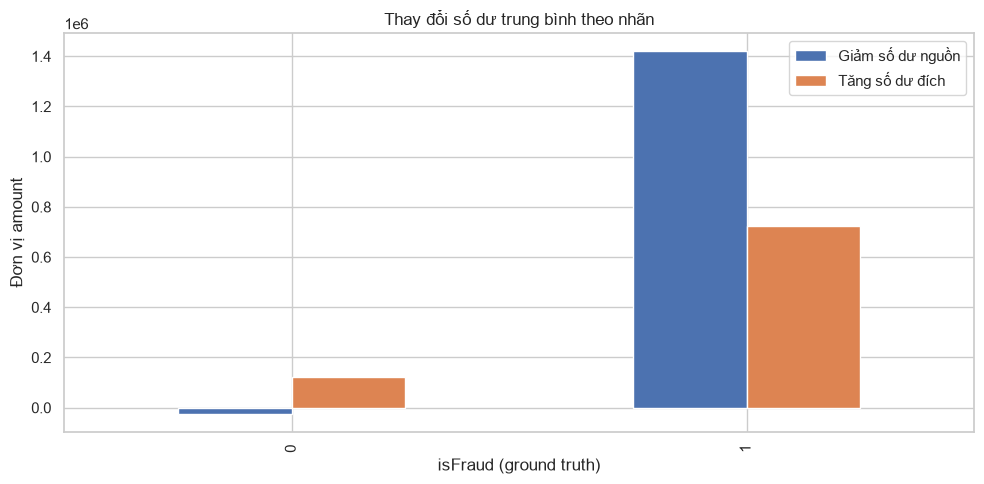

In [3]:
def save_show(name):
    plt.tight_layout(); plt.savefig(FIG_DIR/name,dpi=140,bbox_inches="tight"); plt.show()
fig,ax=plt.subplots(figsize=(10,5)); sns.barplot(data=by_type,x="type",y="transaction_count",ax=ax); ax.set(title="Phân phối giao dịch theo loại",xlabel="Loại giao dịch",ylabel="Số giao dịch"); save_show("01_transactions_by_type.png")
fig,axs=plt.subplots(1,2,figsize=(13,5)); sns.barplot(data=by_type,x="type",y="fraud_count",ax=axs[0]); sns.barplot(data=by_type,x="type",y="fraud_rate",ax=axs[1]); axs[0].set(title="Fraud count theo loại",xlabel="Loại",ylabel="Số fraud"); axs[1].set(title="Fraud rate theo loại",xlabel="Loại",ylabel="Tỷ lệ fraud"); axs[1].yaxis.set_major_formatter(lambda x,pos:f"{x:.2%}"); save_show("02_fraud_by_type.png")
fig,axs=plt.subplots(1,2,figsize=(13,5)); sns.lineplot(data=by_hour,x="HourOfDay",y="fraud_count",marker="o",ax=axs[0]); sns.lineplot(data=by_hour,x="HourOfDay",y="fraud_rate",marker="o",ax=axs[1]); axs[0].set(title="Fraud count theo giờ",xlabel="Giờ mô phỏng trong ngày",ylabel="Số fraud"); axs[1].set(title="Fraud rate theo giờ",xlabel="Giờ mô phỏng trong ngày",ylabel="Tỷ lệ fraud"); axs[1].yaxis.set_major_formatter(lambda x,pos:f"{x:.2%}"); save_show("03_fraud_by_hour.png")
sample=pd.concat(amount_label_parts,ignore_index=True); sample["label"]=sample.isFraud.map({0:"Non-fraud",1:"Fraud"}); fig,ax=plt.subplots(figsize=(10,5)); sns.histplot(data=sample,x="amount",hue="label",bins=60,log_scale=(True,False),element="step",stat="density",common_norm=False,ax=ax); ax.set(title="Phân phối amount: fraud và non-fraud (mẫu cố định)",xlabel="Amount (log scale)",ylabel="Mật độ"); save_show("04_amount_distribution.png")
fig,axs=plt.subplots(1,2,figsize=(13,5)); sns.barplot(data=by_band,x="AmountBand",y="fraud_count",ax=axs[0]); sns.barplot(data=by_band,x="AmountBand",y="fraud_rate",ax=axs[1]); axs[0].set(title="Fraud count theo amount band",xlabel="Amount band",ylabel="Số fraud"); axs[1].set(title="Fraud rate theo amount band",xlabel="Amount band",ylabel="Tỷ lệ fraud"); axs[1].yaxis.set_major_formatter(lambda x,pos:f"{x:.2%}"); save_show("05_fraud_by_amount_band.png")
balance=pd.concat(balance_parts).groupby(level=0).mean(); display(balance); balance.xs("mean",axis=1,level=1).plot(kind="bar",figsize=(10,5),title="Thay đổi số dư trung bình theo nhãn"); plt.xlabel("isFraud (ground truth)"); plt.ylabel("Đơn vị amount"); plt.legend(["Giảm số dư nguồn","Tăng số dư đích"]); save_show("06_balance_patterns.png")

## 3. Kết quả định lượng và kiểm chứng

In [4]:
metrics={"source":CSV_PATH.name,"run_date":pd.Timestamp.now().date().isoformat(),"rows":int(by_type.transaction_count.sum()),"fraud":fraud_total,"fraud_rate":fraud_total/int(by_type.transaction_count.sum()),"total_amount":total_amount,"fraud_amount":fraud_amount,"fraud_amount_share":fraud_amount/total_amount,
"unique_orig":len(orig_counts),"unique_dest":len(dest_counts),"orig_prefix":dict(prefix_orig),"dest_prefix":dict(prefix_dest),"top_orig":orig_counts.most_common(10),"top_dest":dest_counts.most_common(10),"top_fraud_orig":fraud_orig.most_common(10),"top_fraud_dest":fraud_dest.most_common(10),"old_dest_zero_fraud":old_dest_zero_fraud,"old_dest_zero_fraud_rate":old_dest_zero_fraud/fraud_total,"full_drain_fraud":full_drain_fraud,"full_drain_fraud_rate":full_drain_fraud/fraud_total,
"max_fraud_count_hour":int(by_hour.loc[by_hour.fraud_count.idxmax(),"HourOfDay"]),"max_fraud_rate_hour":int(by_hour.loc[by_hour.fraud_rate.idxmax(),"HourOfDay"]),"max_fraud_count_day":int(by_day.loc[by_day.fraud_count.idxmax(),"StepDay"]),"max_fraud_rate_day":int(by_day.loc[by_day.fraud_rate.idxmax(),"StepDay"]),
"by_type":by_type.to_dict("records"),"by_hour":by_hour.to_dict("records"),"by_day":by_day.to_dict("records"),"by_band":by_band.astype({"AmountBand":"str"}).to_dict("records")}
(OUT_DIR/"eda_metrics.json").write_text(json.dumps(metrics,ensure_ascii=False,indent=2),encoding="utf-8")
print(json.dumps({k:v for k,v in metrics.items() if not k.startswith("by_")},ensure_ascii=False,indent=2))
assert metrics["rows"]==6_362_620 and fraud_total==8_213 and set(by_type.loc[by_type.fraud_count.gt(0),"type"])=={"TRANSFER","CASH_OUT"}
print("PASS: tổng số, ground truth và domain fraud theo type đã được kiểm chứng.")

{
  "source": "PS_20174392719_1491204439457_log.csv",
  "run_date": "2026-08-12",
  "rows": 6362620,
  "fraud": 8213,
  "fraud_rate": 0.001290820448180152,
  "total_amount": 1144392944759.77,
  "fraud_amount": 12056415427.84,
  "fraud_amount_share": 0.010535206008606487,
  "unique_orig": 6353307,
  "unique_dest": 2722362,
  "orig_prefix": {
    "C": 6362620
  },
  "dest_prefix": {
    "C": 4211125,
    "M": 2151495
  },
  "top_orig": [
    [
      "C2098525306",
      3
    ],
    [
      "C400299098",
      3
    ],
    [
      "C1999539787",
      3
    ],
    [
      "C1065307291",
      3
    ],
    [
      "C545315117",
      3
    ],
    [
      "C1976208114",
      3
    ],
    [
      "C1784010646",
      3
    ],
    [
      "C1530544995",
      3
    ],
    [
      "C1902386530",
      3
    ],
    [
      "C1677795071",
      3
    ]
  ],
  "top_dest": [
    [
      "C1286084959",
      113
    ],
    [
      "C985934102",
      109
    ],
    [
      "C665576141",
      105